In [1]:
import sys
from pathlib import Path

project_root = Path("/home/atibisiklet/major_proj/OptiCommPy")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc
from scipy import signal
from scipy import constants as const
import tensorflow as tf
from tensorflow.keras import layers, Model, initializers, Sequential

from optic.models.devices import mzm, photodiode, edfa, iqm, coherentReceiver, pdmCoherentReceiver, basicLaserModel
from optic.models.channels import linearFiberChannel, ssfm
from optic.comm.modulation import modulateGray, grayMapping
from optic.comm.sources import bitSource, symbolSource
from optic.dsp.core import upsample, pulseShape, pnorm, anorm, signalPower, firFilter, decimate, symbolSync,phaseNoise, gaussianComplexNoise

try:
    from optic.dsp.coreGPU import checkGPU
    if checkGPU():
        from optic.dsp.coreGPU import firFilter
    else:
        from optic.dsp.core import firFilter
except ImportError:
    from optic.dsp.core import firFilter

from optic.utils import parameters, dBm2W, ber2Qfactor
from optic.plot import eyediagram, pconst, plotPSD

from tqdm.notebook import tqdm
import scipy as sp
import scipy.constants as const

try:
    from optic.models.modelsGPU import manakovSSF
except:
    from optic.models.channels import manakovSSF

from optic.dsp.equalization import edc, mimoAdaptEqualizer, ffe
from optic.dsp.carrierRecovery import cpr
from optic.comm.metrics import fastBERcalc, monteCarloGMI, monteCarloMI, calcEVM, bert
from optic.dsp.clockRecovery import gardnerClockRecovery


import logging as logg
logg.basicConfig(level=logg.INFO, format='%(message)s', force=True)
import time

I0000 00:00:1775226048.592593   57914 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775226048.718143   57914 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775226050.578628   57914 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
from IPython.core.display import HTML
from IPython.core.pylabtools import figsize

HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

In [3]:
# --------------------------------------------------------------------------------------------------------------------------------------
# Power Amplifier (PA) Functions
# ---------------------------------------------------------------------------------------------------------------------------------------

def rapp_pa(x, Vsat, p=2.0):
    """
    Memoryless Rapp PA model for complex baseband input.

    Parameters
    ----------
    x : np.ndarray
        Complex input waveform in volts.
    Vsat : float
        Saturation voltage/amplitude.
    p : float
        Rapp smoothness exponent.

    Returns
    -------
    y : np.ndarray
        Output after memoryless PA nonlinearity.
    """
    mag = np.abs(x)
    gain = 1.0 / (1.0 + (mag / Vsat) ** (2 * p)) ** (1.0 / (2 * p))
    return x * gain


def butter_lpf_complex(x, Fs, f3dB, order=3):
    """
    Apply an order-N Butterworth LPF to a complex baseband waveform.
    """
    wn = f3dB / (Fs / 2)

    if wn >= 1.0:
        raise ValueError(
            f"Butterworth cutoff must be below Nyquist. Got f3dB={f3dB/1e9:.2f} GHz, "
            f"Fs/2={(Fs/2)/1e9:.2f} GHz."
        )

    b, a = signal.butter(order, wn, btype='low')

    y_i = signal.lfilter(b, a, np.real(x))
    y_q = signal.lfilter(b, a, np.imag(x))

    return y_i + 1j * y_q


def pa_model_physical(x, Fs, gain_linear, BLPF_enable, BO_dB=5.0, p=2.0, f3dB=10e9, order=3):
    """
    Physical PA model:
        x -> linear gain -> Rapp compression -> Butterworth LPF

    Parameters
    ----------
    x : np.ndarray
        Complex baseband input waveform (dimensionless DSP waveform).
    Fs : float
        Sample rate [Hz].
    gain_linear : float
        Small-signal linear voltage gain. This sets the nominal IQM drive level.
    BO_dB : float
        Back-off in dB, used to set Vsat relative to the RMS value AFTER gain.
    p : float
        Rapp exponent.
    f3dB : float
        PA 3-dB bandwidth [Hz].
    order : int
        Butterworth filter order.

    Returns
    -------
    y : np.ndarray
        PA output waveform in volts, ready to drive the IQM.
    info : dict
        Diagnostic information.
    """

    # 1) Linear gain stage -> now waveform is in volts
    x_amp = gain_linear * x

    # 2) Compute RMS after gain
    Vrms_in = np.sqrt(np.mean(np.abs(x_amp) ** 2))

    # 3) Saturation voltage from back-off
    Vsat = Vrms_in * 10 ** (BO_dB / 20)

    # 4) Nonlinear compression
    y_nl = rapp_pa(x_amp, Vsat=Vsat, p=p)

    # 5) PA bandwidth limitation
    if BLPF_enable:
        y = butter_lpf_complex(y_nl, Fs=Fs, f3dB=f3dB, order=order)
    else:
        y = y_nl

    info = {
        "gain_linear": gain_linear,
        "Vrms_in_V": Vrms_in,
        "Vsat_V": Vsat,
        "BO_dB": BO_dB,
        "p": p,
        "f3dB_Hz": f3dB,
        "peak_out_V": np.max(np.abs(y)),
        "rms_out_V": np.sqrt(np.mean(np.abs(y) ** 2)),
    }

    return y, info

In [4]:
def perf_calc(symbTx, y_CPR_1, d_, M, paramSymb):
    """Performance Metric Exploration for Single Polarization"""
    d = d_
    discard = 5000
    ind = np.arange(discard, len(symbTx) - discard)
    
    # Remove phase ambiguity for all M (optional: for QAM)
    if M in [4, 16, 32, 64, 128]:
        d = symbTx  # or processed reference symbols

    # Compute metrics
    BER, SER, SNR = fastBERcalc(y_CPR_1[ind], d[ind], M, 'qam', px=paramSymb.px)
    EVM = calcEVM(y_CPR_1[ind], M, 'qam', d[ind])
    Qfactor = ber2Qfactor(BER[0])

    print(' SER: %.3e,  '%(SER[0]))
    print(' BER: %.3e   '%(BER[0]))
    print(' SNR: %.3f dB'%(SNR[0]))
    print(' EVM: %.3f %%'%(EVM[0]*100))
    print(' Qfactor: %.3f,  '%(Qfactor))

    return BER[0], SER[0], SNR[0], EVM[0], Qfactor

In [5]:
# --------------------------------------------------------------------------------------------------------------------------------------
# Parameters Configuration of Optical System
# ---------------------------------------------------------------------------------------------------------------------------------------


# -----------------------------------------------
# Transmitter Parameters
#-------------------------------------------------

# 1) General Parameters
SpS = 16                 # samples per symbol
Rs = 32e9                # symbol rate [baud]
Fs = Rs * SpS            # sampling frequency [Hz]
M = 16                   # QPSK -> M=4, constType='qam'
nBits = 400000           # total bits to generate
rollOff = 0.01           # RRC roll-off
nFilterTaps = 1024       # RRC filter taps
mzmScale = 1             # IQM drive scale = "modulation depth" (0.5 is default in OptiCommPy)
Vpi = 2                  # IQM pi Voltage  (2V is defualt in OpticommPy)
P_launch_dBm = 0         # desired launched optical power [dBm] -- for 4QAM try 6 dbm -- for 16QAM 0 was good
laserLinewidth = 100e3   # Hz (set e.g. 100e3 for phase noise), setting laserLineWidth to 0, models the ideal case 

# 2) Symbol Source Parameters
paramSymb = parameters()
paramSymb.nSymbols = int(nBits // np.log2(M))  # symbols = bits / log2(M)
paramSymb.M = M
paramSymb.constType = "qam"                    # 'qam' with M=4 -> QPSK
paramSymb.dist = "uniform"                     # uniform symbol probabilities
paramSymb.seed = 444
paramSymb.shapingFactor = 0

constSymb = grayMapping(paramSymb.M, paramSymb.constType)
if paramSymb.dist == "uniform":
   px = np.ones(paramSymb.M) / paramSymb.M
elif paramSymb.dist == "maxwell-boltzmann":
   px = np.exp(-paramSymb.shapingFactor * np.abs(constSymb) ** 2)
   px = px / np.sum(px)
else:
   raise ValueError("Invalid probability distribution.")
paramSymb.px = px

# 3) UpSampling and FIR Parameters
paramPulse = parameters()
paramPulse.pulseType = "rrc"
paramPulse.nFilterTaps = nFilterTaps
paramPulse.rollOff = rollOff
paramPulse.SpS = SpS

# 4) IQM Parameters
paramIQM = parameters()
paramIQM.Vpi = Vpi
paramIQM.VbI = -Vpi
paramIQM.VbQ = -Vpi
paramIQM.Vphi = Vpi/2

# 5) Optical Carrier / LO field (Ein)
sigTx_length = paramSymb.nSymbols * SpS
if laserLinewidth and laserLinewidth > 0:
    phi_pn = phaseNoise(laserLinewidth, sigTx_length, 1 / Fs, seed=123)
    sigLO = np.exp(1j * phi_pn)
else:
    sigLO = np.ones(sigTx_length, dtype=complex)

# 6) PA parameters 
PA_enable = True     # enable flag. If "False", the PA is skipped
PA_BO_dB = 3         # 7 = weak, 5 = moderate, 3 = strong
PA_p = 2.0           # paper says typically p=2
PA_f3dB = 18.5e9     # frequency of 3 dB
BLPF_enable = True


# -----------------------------------------------
# Channel Parameters
#------------------------------------------------

# 1) Optical Channel Parameters
paramCh = parameters()
paramCh.Ltotal = 80       # total link distance [km]
paramCh.Lspan  = 80        # span length [km]
paramCh.alpha = 0.2        # fiber loss parameter [dB/km]
paramCh.D = 16             # fiber dispersion parameter [ps/nm/km]
paramCh.gamma = 1.3        # fiber nonlinear parameter [1/(W.km)]
paramCh.Fc = 193.1e12      # central optical frequency of the WDM spectrum
paramCh.hz = 0.5           # step-size of the split-step Fourier method [km]
paramCh.prgsBar = True     # show progress bar
paramCh.Fs = Rs*SpS        # sampling rate
paramCh.amp = 'edfa'       # type of amplifiers
paramCh.NF = 4.5           # Noise Figure of each amplirifer [dB]
#paramCh.seed = 456

paramASE = parameters()
paramASE.nStages = 1              # number of EDFA stages to simulate (1-10)
paramASE.G = 20.0                 # gain per stage in dB (for noise calculation only)
paramASE.NF = 4.5                 # noise figure per stage in dB (scalar or list)
paramASE.Fc = 193.1e12            # central optical frequency [Hz]
paramASE.Fs = Rs * SpS            # sampling frequency [Hz]
paramASE.Rs = Rs                  # symbol rate [Hz] (for noise bandwidth)
#paramASE.seed = 456              

# -----------------------------------------------
# Receiver Parameters
#------------------------------------------------

# 1) local oscillator (LO) parameters:
FO  = -128e6                # frequency offset
paramLO = parameters()
paramLO.P = 10              # power in dBm
paramLO.lw = 100e3          # laser linewidth
paramLO.RIN_var = 0
paramLO.Fs = Fs
paramLO.seed = 789 # random seed for noise generation
paramLO.freqShift = 0 + FO  # downshift of the channel to be demodulated add frequency offset

# 2) Front-End Parameters and photodiode paramters

# Frontend parameters
paramFE = parameters()
paramFE.Fs = Fs

# Photodiodes parameters
paramPD = parameters()
paramPD.B = Rs
paramPD.Fs = Fs
paramPD.ideal = True
paramPD.seed = 1011

# 3) Pulseshaping in the reciever using rrc filter
paramRxPulse = parameters()
paramRxPulse.SpS = SpS
paramRxPulse.nFilterTaps = nFilterTaps
paramRxPulse.rollOff = rollOff
paramRxPulse.pulseType = "rrc"

# 4) Decimation Parameters
paramDec = parameters()
paramDec.SpSin  = SpS
paramDec.SpSout = 2

# 5) Chromatic Dispersion Parameters
paramEDC = parameters()
paramEDC.L = paramCh.Ltotal
paramEDC.D = paramCh.D
paramEDC.Fc = paramCh.Fc
paramEDC.Rs = Rs
paramEDC.Fs = 2*Rs

# 6) Adaptive Equalization Parameters
paramEq = parameters()
paramEq.nTaps = 35
paramEq.SpS = paramDec.SpSout
paramEq.numIter = 2
paramEq.storeCoeff = False
paramEq.M = M
paramEq.shapingFactor = 0
paramEq.constType = "qam"
paramEq.prgsBar = False

if M == 4:
   paramEq.alg = ['cma','cma'] # QPSK
   paramEq.mu = [5e-3, 1e-3]
else:
   paramEq.alg = ['da-rde','rde'] # M-QAM
   paramEq.mu = [5e-3, 5e-4] 

# 7) Carrier and Phase recovery parameters using bps
paramCPR = parameters()
paramCPR.alg = 'bps'
paramCPR.M   = M
paramCPR.constType ="qam"
paramCPR.shapingFactor = 0
paramCPR.N   = 25
paramCPR.B   = 64
paramCPR.returnPhases = True
paramCPR.Ts = 1/Rs

In [6]:
# ----------------------------------------------
# Simulation of the Optical System
# -----------------------------------------------

def simulate_optical_system(symbTx, paramSymb, paramPulse,paramIQM,sigLO, paramCh, paramLO, paramFE, paramPD, paramRxPulse, paramDec, paramEDC, paramEq, paramCPR, paramASE, P_launch_dBm, BLPF_enable):

    """
   This function simulates the optical transmission of a single-polarization, 
   single-channel 16/4-QAM signal.

    Parameters
    ----------
    Uses Global Parameters defined above

    Returns
    -------
    y_CPR_1 : 
        Received signal at end of DSP chain (after CPR)
    d:
        Noemlaized Symbol Synchronization with the SymbTx. Used in calculations.
    """

    # -----------------------------------------------------------------------------------------------------------------------------------------------------
    # TRANSMITTER

    # 1) Upsampling + pulse shaping
    pulse = pulseShape(paramPulse)
    symbolsUp = upsample(symbTx, SpS)
    sigTx = firFilter(pulse, symbolsUp)

    # 2) Choose nominal small-signal PA gain so the nominal drive is around mzmScale * Vpi
    target_peak_V = mzmScale * Vpi
    peak_sigTx = np.max(np.abs(sigTx))

    if peak_sigTx == 0:
        raise ValueError("sigTx peak is zero; cannot set PA gain.")

    gain_linear = target_peak_V / peak_sigTx

    # 3) Driver amplifier / PA output directly in volts
    if PA_enable:
        u_drive, paInfo = pa_model_physical(
            sigTx,
            Fs=Fs,
            gain_linear=gain_linear,
            BLPF_enable = BLPF_enable,
            BO_dB=PA_BO_dB,
            p=PA_p,
            f3dB=PA_f3dB,
            order=3
        )
    else:
        u_drive = gain_linear * sigTx
        paInfo = {
            "gain_linear": gain_linear,
            "Vrms_in_V": np.sqrt(np.mean(np.abs(u_drive) ** 2)),
            "Vsat_V": None,
            "BO_dB": None,
            "p": None,
            "f3dB_Hz": None,
            "peak_out_V": np.max(np.abs(u_drive)),
            "rms_out_V": np.sqrt(np.mean(np.abs(u_drive) ** 2)),
        }

    # 4) IQ modulation: PA output drives the IQM directly
    sigTxo = iqm(sigLO, u_drive, paramIQM)

    # 5) Set launched optical power
    P_launch_W = dBm2W(P_launch_dBm)
    sigTxo = np.sqrt(P_launch_W) * pnorm(sigTxo)

    # End of Transmitter
    # -----------------------------------------------------------------------------------------------------------------------------------------------------

    # -----------------------------------------------------------------------------------------------------------------------------------------------------
    # CHANNEL

    #sigCh = ssfm(sigTxo, paramCh)

    # Parameter Validation
    # Validate number of EDFA stages
    if not (1 <= paramASE.nStages <= 10):
        raise ValueError(
            f"Number of EDFA stages must be between 1 and 10, got {paramASE.nStages}"
        )
    
    # Convert scalar G and NF to lists if needed
    if np.isscalar(paramASE.G):
        G_list = [paramASE.G] * paramASE.nStages
    else:
        G_list = list(paramASE.G)
        if len(G_list) != paramASE.nStages:
            raise ValueError(
                f"Length of G list ({len(G_list)}) must match nStages ({paramASE.nStages})"
            )
    
    if np.isscalar(paramASE.NF):
        NF_list = [paramASE.NF] * paramASE.nStages
    else:
        NF_list = list(paramASE.NF)
        if len(NF_list) != paramASE.nStages:
            raise ValueError(
                f"Length of NF list ({len(NF_list)}) must match nStages ({paramASE.nStages})"
            )
    
    # Validate gain values (must be positive)
    for i, G in enumerate(G_list):
        if G <= 0:
            raise ValueError(
                f"EDFA gain must be positive, got {G} dB for stage {i}"
            )
    
    # Validate noise figure values (must be >= 3 dB)
    for i, NF in enumerate(NF_list):
        if NF < 3:
            raise ValueError(
                f"EDFA noise figure must be >= 3 dB, got {NF} dB for stage {i}"
            )
    
    # Validate carrier frequency and sampling frequency
    if paramASE.Fc <= 0:
        raise ValueError(
            f"Carrier frequency must be positive, got {paramASE.Fc} Hz"
        )
    
    if paramASE.Fs <= 0:
        raise ValueError(
            f"Sampling frequency must be positive, got {paramASE.Fs} Hz"
        )
    

    sigCh = sigTxo.copy()

    # Add ASE noise from each stage
    # In back-to-back: just add noise, no amplification
    for i in range(paramASE.nStages):
        # Convert gain and noise figure to linear scale
        G_lin = 10 ** (G_list[i] / 10)
        NF_lin = 10 ** (NF_list[i] / 10)
        
        # Calculate spontaneous emission factor (nsp)
        # nsp = (G * NF - 1) / (2 * (G - 1))
        nsp = (G_lin * NF_lin - 1) / (2 * (G_lin - 1))
        
        # Calculate ASE noise power spectral density
        # N_ase = (G - 1) * nsp * h * Fc [W/Hz]
        N_ase = (G_lin - 1) * nsp * const.h * paramASE.Fc
        
        # Calculate total ASE noise power over the sampling bandwidth
        # P_noise = N_ase * Fs [W]
        p_noise = N_ase * paramASE.Fs
        
        # Generate complex Gaussian ASE noise
        seed = paramASE.seed + i if hasattr(paramASE, 'seed') and paramASE.seed is not None else None
        noise = gaussianComplexNoise(sigCh.shape, p_noise, seed)

        sigCh = sigCh + noise
        
    B_ref = 12.5e9
    p_signal = np.mean(np.abs(sigTxo)**2)
    p_noise_ref = N_ase * B_ref
    OSNR_lin = p_signal / p_noise_ref
    OSNR_dB = 10 * np.log10(OSNR_lin)

    # End of CHANNEL
    # -----------------------------------------------------------------------------------------------------------------------------------------------------

    # -----------------------------------------------------------------------------------------------------------------------------------------------------
    # RECEIVER

    # 1) Generate CW laser LO field
    # Parameter which might change so needs to be in the function
    paramLO.Ns = len(sigCh)
    sigLO_Rx = basicLaserModel(paramLO)

    # 2) Coherent Reciever for single-polarization.
    # Contains a 90 hybrid, two balanced photodiodes and iqmixing
    sigRxFrontEnd = coherentReceiver(sigCh, sigLO_Rx, paramFE, paramPD)

    # 3) Pusleshaping Function
    pulse = pulseShape(paramRxPulse) 
    sigRxPulseShape = firFilter(pulse, sigRxFrontEnd)

    # 4) Decimation
    sigRxDecimation = decimate(sigRxPulseShape, paramDec)

    # 5) Chromatic Dispersion Compensation for non-linear channel
    #sigRxCD = edc(sigRxDecimation, paramEDC)

    # 6) Symbol Synchronization with the SymbTx
    symbRxCD = symbolSync(sigRxDecimation, symbTx, 2)

    # 7) Power Normalization
    x = pnorm(sigRxDecimation) 
    d = pnorm(symbRxCD)

    # 8) Adaptive Equalization Parameter which might change
    paramEq.L = [int(0.2*d.shape[0]), int(0.8*d.shape[0])]
    y_EQ = mimoAdaptEqualizer(x, paramEq, d)

    # 9) Carrier and Phase recovery using bps in the parameters
    y_CPR_1, θ = cpr(y_EQ, paramCPR)

    return y_CPR_1, d, OSNR_dB 
    # End of RECEIVER
    # -----------------------------------------------------------------------------------------------------------------------------------------------------

ASE Gain Sweep:   0%|          | 0/12 [00:00<?, ?dB/s]

Running adaptive equalizer...
da-rde - training stage #0
da-rde pre-convergence training iteration #0
da-rde MSE = 0.218003.
da-rde pre-convergence training iteration #1
da-rde MSE = 0.218013.
rde - training stage #1
rde MSE = 0.057483.
Running frequency offset compensation...
Estimated frequency offset (MHz): [128.24]
Running BPS carrier phase recovery...
Estimated linewidth: 90908.181 kHz


 SER: 9.274e-01,  
 BER: 4.448e-01   
 SNR: -2.912 dB
 EVM: 99.950 %
 Qfactor: -8.573,  


Running adaptive equalizer...
da-rde - training stage #0
da-rde pre-convergence training iteration #0
da-rde MSE = 0.160894.
da-rde pre-convergence training iteration #1
da-rde MSE = 0.161065.
rde - training stage #1
rde MSE = 0.054457.
Running frequency offset compensation...
Estimated frequency offset (MHz): [128.24]
Running BPS carrier phase recovery...
Estimated linewidth: 40038.307 kHz


 SER: 8.300e-01,  
 BER: 4.074e-01   
 SNR: -2.750 dB
 EVM: 99.661 %
 Qfactor: -6.301,  


...

 SER: 3.889e-04,  
 BER: 9.722e-05   
 SNR: 20.763 dB
 EVM: 0.855 %
 Qfactor: 5.713,  


Running adaptive equalizer...
da-rde - training stage #0
da-rde pre-convergence training iteration #0
da-rde MSE = 0.027144.
da-rde pre-convergence training iteration #1
da-rde MSE = 0.026947.
rde - training stage #1
rde MSE = 0.018560.
Running frequency offset compensation...
Estimated frequency offset (MHz): [128.24]
Running BPS carrier phase recovery...
Estimated linewidth: 292.054 kHz


 SER: 2.556e-04,  
 BER: 6.389e-05   
 SNR: 21.079 dB
 EVM: 0.798 %
 Qfactor: 5.833,  


Running adaptive equalizer...
da-rde - training stage #0
da-rde pre-convergence training iteration #0
da-rde MSE = 0.026172.
da-rde pre-convergence training iteration #1
da-rde MSE = 0.025970.
rde - training stage #1
rde MSE = 0.017974.
Running frequency offset compensation...
Estimated frequency offset (MHz): [128.24]
Running BPS carrier phase recovery...
Estimated linewidth: 289.845 kHz


 SER: 2.111e-04,  
 BER: 5.278e-05   
 SNR: 21.285 dB
 EVM: 0.763 %
 Qfactor: 5.885,  


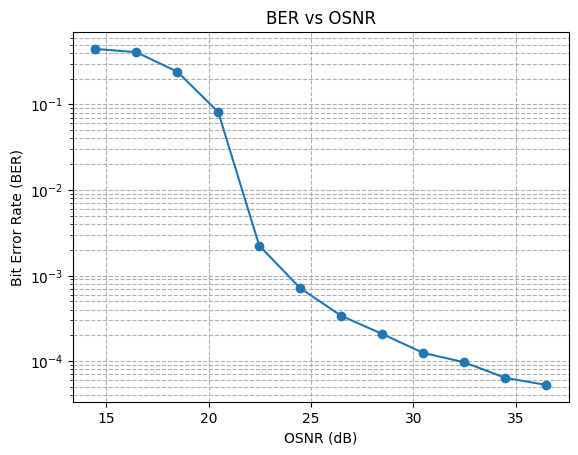

In [7]:
results = []
ase_G_dB_vals = [42, 40, 38, 36, 34, 32, 30, 28, 26, 24, 22, 20]

symbTx = symbolSource(paramSymb)

for k, G in enumerate(tqdm(ase_G_dB_vals, desc="ASE Gain Sweep", unit="dB")):
    paramASE.G = G

    y_CPR_1, d, OSNR_dB = simulate_optical_system(
        symbTx=symbTx,
        paramSymb=paramSymb,
        paramPulse=paramPulse,
        paramIQM=paramIQM,
        sigLO=sigLO,
        paramCh=paramCh,
        paramLO=paramLO,
        paramFE=paramFE,
        paramPD=paramPD,
        paramRxPulse=paramRxPulse,
        paramDec=paramDec,
        paramEDC=paramEDC,
        paramEq=paramEq,
        paramCPR=paramCPR,
        paramASE=paramASE,
        P_launch_dBm=P_launch_dBm,
        BLPF_enable=BLPF_enable)

    BER, SER, SNR, EVM, Qfactor = perf_calc(symbTx, y_CPR_1, d, M, paramSymb)

    results.append({
     "ASE_G_dB": G,
     "OSNR_dB": OSNR_dB,
     "BER": BER,
     "SER": SER,
     "SNR": SNR,  
     "EVM": EVM,
     "Qfactor": Qfactor
})

OSNR_dB_vals = [r['OSNR_dB'] for r in results]
ber_res = [r['BER'] for r in results]

plt.semilogy(OSNR_dB_vals, ber_res, marker='o', linestyle='-')
plt.xlabel('OSNR (dB)')
plt.ylabel('Bit Error Rate (BER)')
plt.title('BER vs OSNR')
plt.grid(True, which='both', ls='--')
plt.show()



In [8]:
print("\n==================== SUMMARY TABLE ====================\n")
for r in results:
    print(f"OSNR={r['OSNR_dB']}, ASE_G={r['ASE_G_dB']}: "
          f"BER={r['BER']:.2e}, SER={r['SER']:.2e}, "
          f"SNR={r['SNR']:.2f} dB, EVM={r['EVM']*100:.1f} %, Q={r['Qfactor']:.2f}")


==================== SUMMARY TABLE ====================

OSNR=14.470914021951778, ASE_G=42: BER=4.45e-01, SER=9.27e-01, SNR=-2.91 dB, EVM=99.9 %, Q=-8.57
OSNR=16.470970890670586, ASE_G=40: BER=4.07e-01, SER=8.30e-01, SNR=-2.75 dB, EVM=99.7 %, Q=-6.30
OSNR=18.471061023041283, ASE_G=38: BER=2.41e-01, SER=5.20e-01, SNR=-1.60 dB, EVM=92.4 %, Q=-1.53
OSNR=20.471203877053817, ASE_G=36: BER=8.16e-02, SER=1.98e-01, SNR=5.79 dB, EVM=24.6 %, Q=1.44
OSNR=22.471430295031514, ASE_G=34: BER=2.24e-03, SER=8.90e-03, SNR=16.48 dB, EVM=2.2 %, Q=4.54
OSNR=24.47178916752442, ASE_G=32: BER=7.14e-04, SER=2.83e-03, SNR=17.77 dB, EVM=1.7 %, Q=5.04
OSNR=26.47235800284711, ASE_G=30: BER=3.39e-04, SER=1.34e-03, SNR=18.84 dB, EVM=1.3 %, Q=5.31
OSNR=28.473259698721925, ASE_G=28: BER=2.08e-04, SER=8.22e-04, SNR=19.68 dB, EVM=1.1 %, Q=5.48
OSNR=30.474689173971363, ASE_G=26: BER=1.25e-04, SER=4.89e-04, SNR=20.32 dB, EVM=0.9 %, Q=5.64
OSNR=32.47695570379228, ASE_G=24: BER=9.72e-05, SER=3.89e-04, SNR=20.76 dB, EVM=0.9